## PART-1

In [33]:
import os
import numpy as np
import librosa
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES_PATH = os.path.join(BASE_PATH, "genres_stems")
ESC50_PATH = os.path.join(BASE_PATH, "ESC-50-master", "audio")
MASHUPS_PATH = os.path.join(BASE_PATH, "mashups")

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

#### Q1) What is the mean duration (in seconds) of the Jazz genre stems in train dataset?
#### Ans: `30.033` secs

In [34]:
jazz = os.path.join(GENRES_PATH, "jazz")
durations = []
    
for song_folder in os.listdir(jazz):
    song_path = os.path.join(jazz, song_folder)
    for stem in STEMS:
        stem_path = os.path.join(song_path, stem)
        duration = librosa.get_duration(path=stem_path)
        durations.append(duration)

mean_duration = np.mean(durations)
print(f"Mean duration of Jazz genre stems: {mean_duration:.4f} seconds")

Mean duration of Jazz genre stems: 30.0330 seconds


#### Q2) What are the unique sample rates present in the dataset?
#### Ans: `[22050, 44100]`

In [35]:
sample_rates = set()
    
# Scanning stems...
for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        for song_folder in os.listdir(genre_path):
            song_path = os.path.join(genre_path, song_folder)
            for stem in STEMS:
                stem_path = os.path.join(song_path, stem)                
                info = sf.info(stem_path)
                sr = info.samplerate
                sample_rates.add(sr)

# Scanning noise files...
for file in os.listdir(ESC50_PATH):
    file_path = os.path.join(ESC50_PATH, file)
    info = sf.info(file_path)
    sr = info.samplerate
    sample_rates.add(sr)
    
# Scanning mashups...
for file in os.listdir(MASHUPS_PATH):
    file_path = os.path.join(MASHUPS_PATH, file)
    info = sf.info(file_path)
    sr = info.samplerate
    sample_rates.add(sr)

unique_rates = sorted(list(sample_rates))
print(f"\nUnique sample rates in entire dataset: {unique_rates}")


Unique sample rates in entire dataset: [22050, 44100]


#### Q3) How many corrupted or zero-byte audio files are present in the train dataset?
#### Ans: `0`

In [36]:
corrupted_files = []
    
for genre in GENRES:
    genre_path = os.path.join(GENRES_PATH, genre)
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        for stem in STEMS:
            stem_path = os.path.join(song_path, stem)
            if os.path.getsize(stem_path) == 0: # zero-byte files
                corrupted_files.append(stem_path)
                continue
                            
            try:
                y, sr = librosa.load(stem_path, sr=None)
                if len(y) == 0: # empty audio files
                    corrupted_files.append(stem_path)
            except Exception as e:
                corrupted_files.append(stem_path)
                print(f"Corrupted: {stem_path} - {e}")
    
print(f"\nTotal corrupted or zero-byte files: {len(corrupted_files)}")


Total corrupted or zero-byte files: 0


#### Q4) What is the average peak amplitude (in dB) for vocal stems in train dataset? 
#### Ans: `-12.494921` dB

In [37]:
peak_amplitudes = []
    
for genre in GENRES:
    genre_path = os.path.join(GENRES_PATH, genre)
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        vocals_path = os.path.join(song_path, "vocals.wav")
        try:
            y, sr = librosa.load(vocals_path, sr=None)
            peak_amp = np.max(np.abs(y))
            if peak_amp > 0:
                peak_db = 20 * np.log10(peak_amp)
            else:
                peak_db = -np.inf  # or skip this file
                            
            if np.isfinite(peak_db):
                peak_amplitudes.append(peak_db)
        except Exception as e:
            print(f"Error loading {vocals_path}: {e}")
    
avg_peak_db = np.mean(peak_amplitudes)
print(f"\nAverage peak amplitude for vocal stems: {avg_peak_db:.6f} dB")


Average peak amplitude for vocal stems: -12.494922 dB


#### Q5) What is the mean spectral centroid for 'blues' genre in the train dataset?
#### Ans: `2296.782737` Hz

In [38]:
blues = os.path.join(GENRES_PATH, "blues")
spectral_centroids = []
    
for song_folder in os.listdir(blues):
    song_path = os.path.join(blues, song_folder)
    for stem in STEMS:
        stem_path = os.path.join(song_path, stem)
        try:
            y, sr = librosa.load(stem_path, sr=None)
            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
            mean_cent = np.mean(centroid)
            spectral_centroids.append(mean_cent)
        except Exception as e:
            print(f"Error loading {stem_path}: {e}")
    
mean_centroid = np.mean(spectral_centroids)
print(f"\nMean spectral centroid for blues genre: {mean_centroid:.6f} Hz")


Mean spectral centroid for blues genre: 2296.782737 Hz


#### Q6) Which genre in the train dataset has the highest mean spectral centroid?
#### Ans: `metal`

In [39]:
genre_centroids = {}
    
for genre in GENRES:
    genre_path = os.path.join(GENRES_PATH, genre)
    spectral_centroids = []
    
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        for stem in STEMS:
            stem_path = os.path.join(song_path, stem)
            try:
                y, sr = librosa.load(stem_path, sr=None)
                centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
                mean_cent = np.mean(centroid)
                spectral_centroids.append(mean_cent)
            except Exception as e:
                print(f"Error loading {stem_path}: {e}")

    if spectral_centroids:
        genre_centroids[genre] = np.mean(spectral_centroids)
        print(f"{genre}: {genre_centroids[genre]:.2f} Hz")
    
highest_genre = max(genre_centroids, key=genre_centroids.get)
print(f"\nGenre with highest mean spectral centroid: {highest_genre}")
print(f"Value: {genre_centroids[highest_genre]:.6f} Hz")

blues: 2296.78 Hz
classical: 1674.79 Hz
country: 2266.72 Hz
disco: 2454.15 Hz
hiphop: 2370.79 Hz
jazz: 2544.11 Hz
metal: 2579.32 Hz
pop: 2440.88 Hz
reggae: 2404.57 Hz
rock: 2250.08 Hz

Genre with highest mean spectral centroid: metal
Value: 2579.324315 Hz


#### Q7) How many stem audio files in the train dataset contain silence in the first 0.5 seconds?
#### Ans: `333`

In [40]:
threshold = 1e-4
silence_count = 0

for genre in GENRES:
    genre_path = os.path.join(GENRES_PATH, genre)
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        for stem in STEMS:
            stem_path = os.path.join(song_path, stem)
            try:
                y, sr = librosa.load(stem_path, sr=None, duration=0.5)
                if len(y) == 0 or np.max(np.abs(y)) < threshold:
                    silence_count += 1
            except Exception as e:
                print(f"Error loading {stem_path}: {e}")
    
print(f"\nFiles with silence in first 0.5 seconds: {silence_count}")


Files with silence in first 0.5 seconds: 333


## PART-2

/tmp/ipykernel_55/1449395747.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



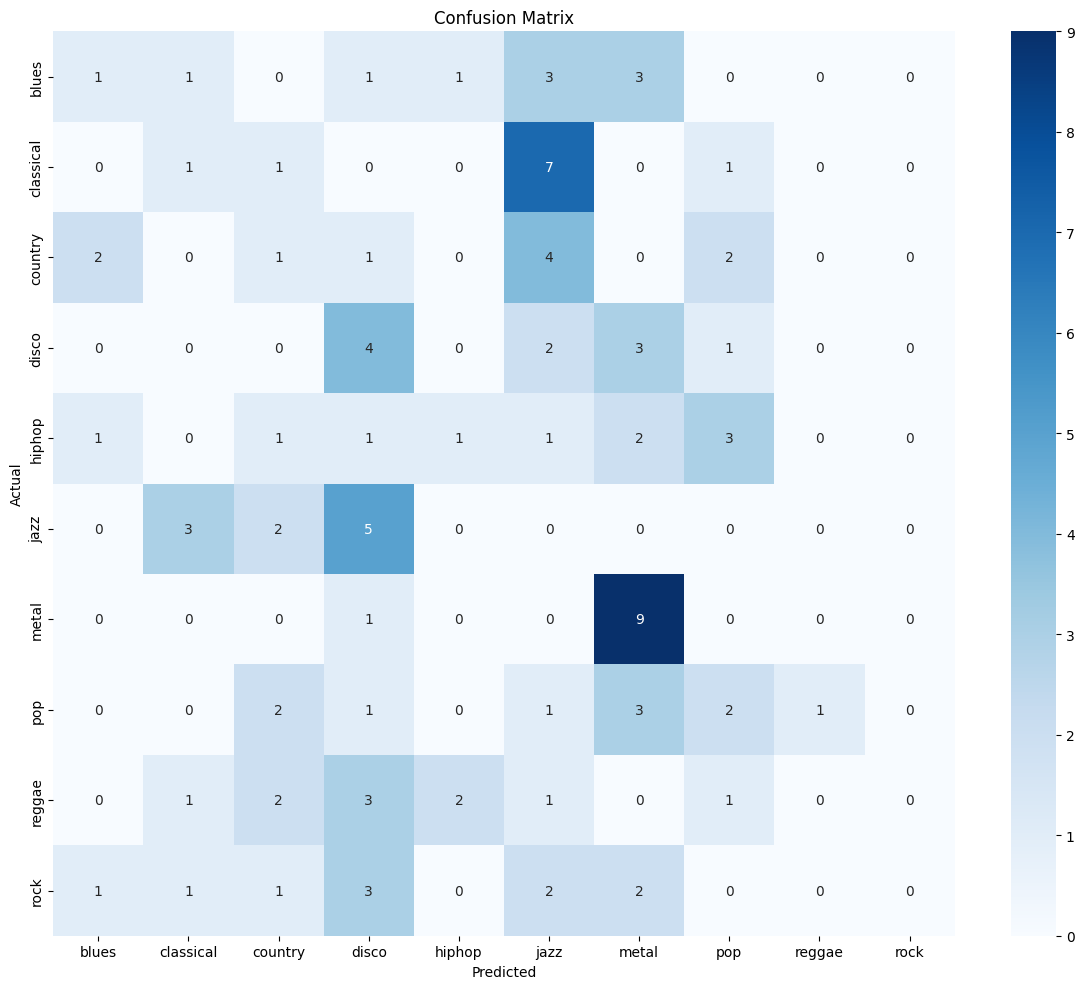


----------------------------------------------------------------------
TP, TN, FP, FN for Each Genre
----------------------------------------------------------------------
    Genre  TP  TN  FP  FN
    blues   1  86   4   9
classical   1  84   6   9
  country   1  81   9   9
    disco   4  74  16   6
   hiphop   1  87   3   9
     jazz   0  69  21  10
    metal   9  77  13   1
      pop   2  82   8   8
   reggae   0  89   1  10
     rock   0  90   0  10

----------------------------------------------------------------------
ANSWERS TO QUESTIONS
----------------------------------------------------------------------

1. Validation Macro F1 Score: 0.1523

2. Precision of hiphop: 0.2500

3. Recall of pop: 0.2000

4. Model Accuracy: 0.1900

5. Genre with highest True Positives: metal (TP = 9)

6. Genre with lowest False Negatives: metal (FN = 1)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]:  # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- 4. Predictions and Metrics ---

y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred, labels=GENRES)
cr = classification_report(y_val, y_pred, labels=GENRES, target_names=GENRES)
accuracy = accuracy_score(y_val, y_pred)

print("Detailed Classification Report:")
print(cr)

# --- 5. Visualize Confusion Matrix ---

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

metrics_data = []

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    metrics_data.append({
        'Genre': genre,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN
    })
    
metrics_df = pd.DataFrame(metrics_data)

print("\n" + "-" * 70)
print("TP, TN, FP, FN for Each Genre")
print("-" * 70)
print(metrics_df.to_string(index=False))

print("\n" + "-" * 70)
print("ANSWERS TO QUESTIONS")
print("-" * 70)

print(f"\n1. Validation Macro F1 Score: {macro_f1:.4f}")

cr_dict = classification_report(y_val, y_pred, labels=GENRES, target_names=GENRES, output_dict=True)
hiphop_precision = cr_dict['hiphop']['precision']
print(f"\n2. Precision of hiphop: {hiphop_precision:.4f}")

pop_recall = cr_dict['pop']['recall']
print(f"\n3. Recall of pop: {pop_recall:.4f}")

print(f"\n4. Model Accuracy: {accuracy:.4f}")

genre_highest_tp = metrics_df.loc[metrics_df['TP'].idxmax(), 'Genre']
max_tp = metrics_df['TP'].max()
print(f"\n5. Genre with highest True Positives: {genre_highest_tp} (TP = {max_tp})")

genre_lowest_fn = metrics_df.loc[metrics_df['FN'].idxmin(), 'Genre']
min_fn = metrics_df['FN'].min()
print(f"\n6. Genre with lowest False Negatives: {genre_lowest_fn} (FN = {min_fn})")
